185/185 [==============================] - 1s 3ms/step


185/185 [==============================] - 1s 3ms/step
Epoch 1/20
675/675 [==============================] - 8s 7ms/step - loss: 0.0609
Epoch 2/20
675/675 [==============================] - 5s 8ms/step - loss: 0.0571
Epoch 3/20
675/675 [==============================] - 5s 8ms/step - loss: 0.0539
Epoch 4/20
675/675 [==============================] - 5s 8ms/step - loss: 0.0508
Epoch 5/20
675/675 [==============================] - 6s 8ms/step - loss: 0.0491
Epoch 6/20
675/675 [==============================] - 5s 8ms/step - loss: 0.0481
Epoch 7/20
675/675 [==============================] - 5s 8ms/step - loss: 0.0464
Epoch 8/20
675/675 [==============================] - 5s 8ms/step - loss: 0.0451
Epoch 9/20
675/675 [==============================] - 5s 8ms/step - loss: 0.0442
Epoch 10/20
675/675 [==============================] - 5s 8ms/step - loss: 0.0431
Epoch 11/20
675/675 [==============================] - 5s 8ms/step - loss: 0.0423
Epoch 12/20
675/675 [==============================]

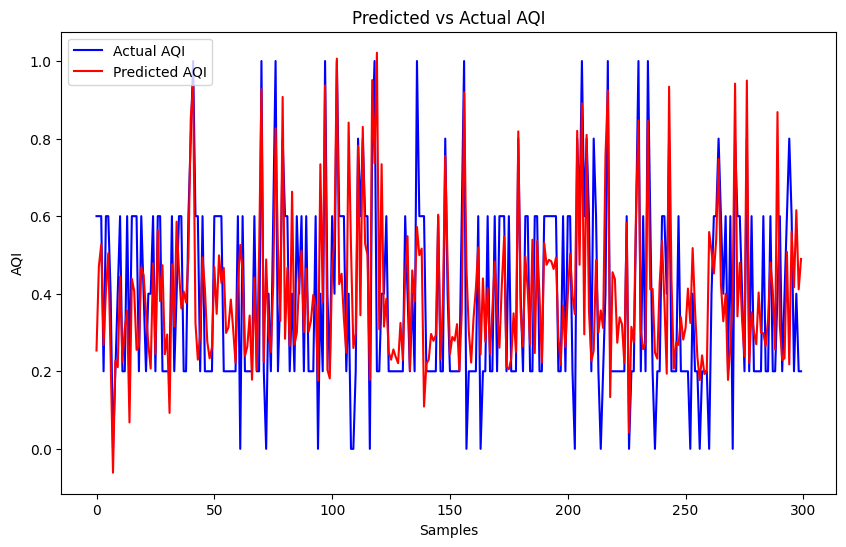

In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

# Load Data
data = pd.read_csv("C:/Users/Ashita Singh/Documents/AQI Project/AirQuality_Cleaned.csv")

# Parse Date Column and Drop it
data['Date'] = pd.to_datetime(data['Date'])
data.drop('Date', axis=1, inplace=True)

# Feature Scaling
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

# Prepare Data for LSTM
def create_sequences(data, step):
    X, y = [], []
    for i in range(len(data) - step):
        X.append(data[i:i+step, :-1])
        y.append(data[i + step, -1])
    return np.array(X), np.array(y)

STEP = 10
X, y = create_sequences(scaled_data, STEP)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Grey Wolf Optimizer
class GreyWolfOptimizer:
    def __init__(self, n_wolves, max_iter):
        self.n_wolves = n_wolves
        self.max_iter = max_iter

    def optimize(self, objective_function):
        wolves = np.random.uniform([10, 0.1, 32], [100, 0.5, 256], (self.n_wolves, 3))
        alpha, beta, delta = wolves[0], wolves[1], wolves[2]

        for iteration in range(self.max_iter):
            for i, wolf in enumerate(wolves):
                wolf = np.clip(wolf, [10, 0.1, 32], [100, 0.5, 256])
                fitness = objective_function(wolf)
                if fitness < objective_function(alpha): alpha = wolf.copy()
                elif fitness < objective_function(beta): beta = wolf.copy()
                elif fitness < objective_function(delta): delta = wolf.copy()

            a = 2 - iteration * (2 / self.max_iter)
            for i, wolf in enumerate(wolves):
                for j in range(3):
                    r1, r2 = np.random.random(2)
                    A = 2 * a * r1 - a
                    C = 2 * r2
                    D_alpha = abs(C * alpha[j] - wolf[j])
                    X1 = alpha[j] - A * D_alpha

                    r1, r2 = np.random.random(2)
                    A = 2 * a * r1 - a
                    C = 2 * r2
                    D_beta = abs(C * beta[j] - wolf[j])
                    X2 = beta[j] - A * D_beta

                    r1, r2 = np.random.random(2)
                    A = 2 * a * r1 - a
                    C = 2 * r2
                    D_delta = abs(C * delta[j] - wolf[j])
                    X3 = delta[j] - A * D_delta

                    wolf[j] = (X1 + X2 + X3) / 3

        return alpha

# Objective Function
def objective_function(params):
    units = int(np.clip(params[0], 10, 100))
    dropout = np.clip(params[1], 0.1, 0.5)
    batch_size = int(np.clip(params[2], 32, 256))

    model = tf.keras.Sequential([
        tf.keras.layers.LSTM(units, input_shape=(STEP, X.shape[2])),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Dense(1)
    ])

    model.compile(loss='mse', optimizer='adam')
    model.fit(X_train, y_train, epochs=10, batch_size=batch_size, verbose=0)
    preds = model.predict(X_test)

    return np.sqrt(mean_squared_error(y_test, preds))

# Run Optimization
gwo = GreyWolfOptimizer(n_wolves=5, max_iter=10)
optimal_params = gwo.optimize(objective_function)

# Final Model with Optimal Parameters
units, dropout, batch_size = int(optimal_params[0]), optimal_params[1], int(optimal_params[2])
final_model = tf.keras.Sequential([
    tf.keras.layers.LSTM(units, input_shape=(STEP, X.shape[2])),
    tf.keras.layers.Dropout(dropout),
    tf.keras.layers.Dense(1)
])

final_model.compile(loss='mse', optimizer='adam')
final_model.fit(X_train, y_train, epochs=20, batch_size=batch_size, verbose=1)

# Predictions and Evaluation
preds = final_model.predict(X_test)
print("Optimal Parameters: ", optimal_params)
print("RMSE: ", np.sqrt(mean_squared_error(y_test, preds)))
print("MAE: ", mean_absolute_error(y_test, preds))
print("R2 Score: ", r2_score(y_test, preds))



# Plotting Predicted vs Actual AQI
plt.figure(figsize=(10, 6))
plt.plot(y_test[:300], label="Actual AQI", color='blue')
plt.plot(preds[:300], label="Predicted AQI", color='red')
plt.title("Predicted vs Actual AQI")
plt.xlabel("Samples")
plt.ylabel("AQI")
plt.legend()
plt.show()


Epoch 1/20
191/191 [==============================] - 7s 23ms/step - loss: 0.0652
Epoch 2/20
191/191 [==============================] - 5s 24ms/step - loss: 0.0575
Epoch 3/20
191/191 [==============================] - 4s 23ms/step - loss: 0.0563
Epoch 4/20
191/191 [==============================] - 5s 24ms/step - loss: 0.0556
Epoch 5/20
191/191 [==============================] - 5s 25ms/step - loss: 0.0543
Epoch 6/20
191/191 [==============================] - 5s 27ms/step - loss: 0.0526
Epoch 7/20
191/191 [==============================] - 5s 28ms/step - loss: 0.0509
Epoch 8/20
191/191 [==============================] - 6s 29ms/step - loss: 0.0499
Epoch 9/20
191/191 [==============================] - 6s 31ms/step - loss: 0.0492
Epoch 10/20
191/191 [==============================] - 6s 31ms/step - loss: 0.0488
Epoch 11/20
191/191 [==============================] - 6s 30ms/step - loss: 0.0479
Epoch 12/20
191/191 [==============================] - 6s 30ms/step - loss: 0.0471
Epoch 13/20
1

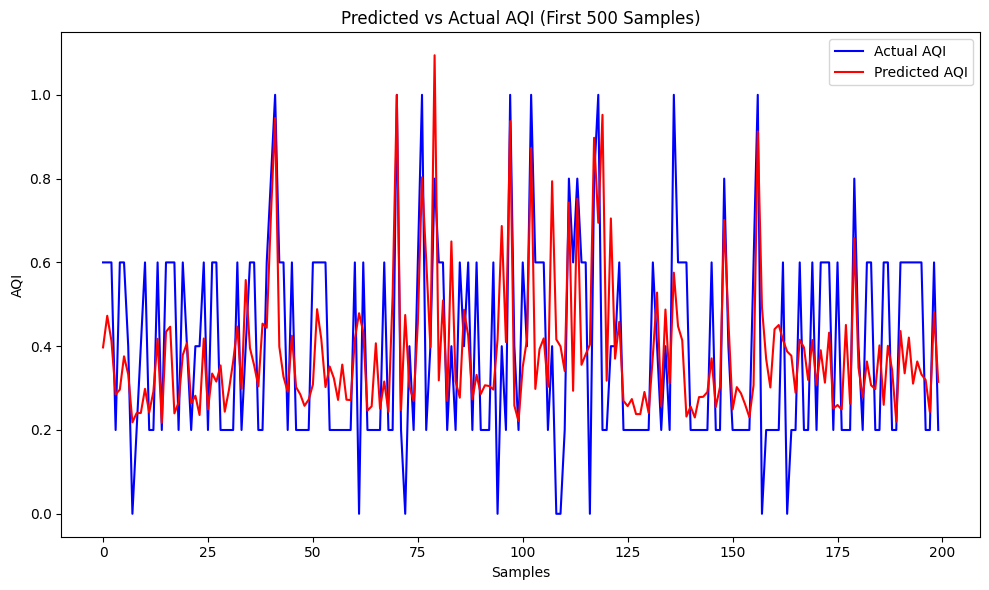

In [2]:
import numpy as np 
import pandas as pd
import tensorflow as tf
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

# Load Data
data = pd.read_csv("C:/Users/Ashita Singh/Documents/AQI Project/AirQuality_Cleaned.csv")

# Parse Date Column and Drop it
data['Date'] = pd.to_datetime(data['Date'])
data.drop('Date', axis=1, inplace=True)

# Feature Scaling
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

# Prepare Data for LSTM
def create_sequences(data, step):
    X, y = [], []
    for i in range(len(data) - step):
        X.append(data[i:i+step, :-1])
        y.append(data[i + step, -1])
    return np.array(X), np.array(y)

STEP = 10
X, y = create_sequences(scaled_data, STEP)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Grey Wolf Optimizer
class GreyWolfOptimizer:
    def __init__(self, n_wolves, max_iter):
        self.n_wolves = n_wolves
        self.max_iter = max_iter

    def optimize(self, objective_function):
        wolves = np.random.uniform([10, 0.1, 32], [100, 0.5, 256], (self.n_wolves, 3))
        alpha, beta, delta = wolves[0], wolves[1], wolves[2]

        for iteration in range(self.max_iter):
            for i, wolf in enumerate(wolves):
                wolf = np.clip(wolf, [10, 0.1, 32], [100, 0.5, 256])
                fitness = objective_function(wolf)
                if fitness < objective_function(alpha): alpha = wolf.copy()
                elif fitness < objective_function(beta): beta = wolf.copy()
                elif fitness < objective_function(delta): delta = wolf.copy()

            a = 2 - iteration * (2 / self.max_iter)
            for i, wolf in enumerate(wolves):
                for j in range(3):
                    r1, r2 = np.random.random(2)
                    A = 2 * a * r1 - a
                    C = 2 * r2
                    D_alpha = abs(C * alpha[j] - wolf[j])
                    X1 = alpha[j] - A * D_alpha

                    r1, r2 = np.random.random(2)
                    A = 2 * a * r1 - a
                    C = 2 * r2
                    D_beta = abs(C * beta[j] - wolf[j])
                    X2 = beta[j] - A * D_beta

                    r1, r2 = np.random.random(2)
                    A = 2 * a * r1 - a
                    C = 2 * r2
                    D_delta = abs(C * delta[j] - wolf[j])
                    X3 = delta[j] - A * D_delta

                    wolf[j] = (X1 + X2 + X3) / 3

        return alpha

# Objective Function (faster training)
def objective_function(params):
    units = int(np.clip(params[0], 10, 100))
    dropout = np.clip(params[1], 0.1, 0.5)
    batch_size = int(np.clip(params[2], 32, 256))

    model = tf.keras.Sequential([
        tf.keras.layers.LSTM(units, input_shape=(STEP, X.shape[2])),
        tf.keras.layers.Dropout(dropout),
        tf.keras.layers.Dense(1)
    ])

    model.compile(loss='mse', optimizer='adam')
    model.fit(X_train, y_train, epochs=5, batch_size=batch_size, verbose=0)  # Reduced epochs
    preds = model.predict(X_test, verbose=0)

    return np.sqrt(mean_squared_error(y_test, preds))

# Run Optimization (faster)
gwo = GreyWolfOptimizer(n_wolves=3, max_iter=5)  # Reduced wolves and iterations
optimal_params = gwo.optimize(objective_function)

# Final Model with Optimal Parameters + EarlyStopping
units, dropout, batch_size = int(optimal_params[0]), optimal_params[1], int(optimal_params[2])
final_model = tf.keras.Sequential([
    tf.keras.layers.LSTM(units, input_shape=(STEP, X.shape[2])),
    tf.keras.layers.Dropout(dropout),
    tf.keras.layers.Dense(1)
])

final_model.compile(loss='mse', optimizer='adam')
early_stop = tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)
final_model.fit(X_train, y_train, epochs=20, batch_size=batch_size, verbose=1, callbacks=[early_stop])

# Predictions and Evaluation
preds = final_model.predict(X_test, verbose=0)
print("Optimal Parameters: ", optimal_params)
print("RMSE: ", np.sqrt(mean_squared_error(y_test, preds)))
print("MAE: ", mean_absolute_error(y_test, preds))
print("R2 Score: ", r2_score(y_test, preds))

# Plotting first 500 Predicted vs Actual AQI
plt.figure(figsize=(10, 6))
plt.plot(y_test[:200], label="Actual AQI", color='blue')
plt.plot(preds[:200], label="Predicted AQI", color='red')
plt.title("Predicted vs Actual AQI (First 500 Samples)")
plt.xlabel("Samples")
plt.ylabel("AQI")
plt.legend()
plt.tight_layout()
plt.show()
